<a href="https://colab.research.google.com/github/JoseAlberto88/Renewable-Energy-Transition-and-Carbon-Emissions/blob/main/Enviromental_Lead.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Person 3.Environmental Lead
### Renewable Energy Transition and Carbon Emissions. Group 9

**Owner:** Jose Alberto Martinez Morales

**Variables:** `CO2_Emissions_Per_Capita`, `PM25_Air_Pollution_ug_m3`

**Python work for this notebook:**

1. Descriptive statistics plus trend charts (2015–2023, by region) for CO2 and PM2.5.
2. Outlier analysis (IQR / Z-score) and missing-data diagnostic, carried over from the Part 1 revision.
3. Export `environmental_summary.csv` plus chart PNGs to the shared `/charts` folder, per the group's shared conventions.

**Before running:** update `DATA_PATH` in the cell below to point at the expanded 115-country panel CSV
(`Renewable_Energy_PESTEL_expanded_indicators.csv`) in your Drive. The **same file** everyone on the
team is using, not a personal copy. If your `/charts` output folder path differs from teammates', update
`CHARTS_DIR` too and tell the group so filenames stay predictable (`environmental_trend_co2.png`, etc.).

## 1. Setup

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Importing the libraries that we're going to use for this project
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path

## 2. Shared chart style. `set_style()` / `save_chart()`

Same helper every teammate should import/paste, so all three analyses look like one report. Colors
come from the group's validated categorical palette (fixed slot order, colorblind-safe pairs), not an
arbitrary matplotlib cycle, identity should always map to the *same* region getting the *same* color
across everyone's charts.

In [3]:
# Fixed categorical order — do not reassign per-chart; a region keeps its slot everywhere.
REGION_COLORS = {
    "_slot_1": "#2a78d6",  # blue
    "_slot_2": "#eb6834",  # orange
    "_slot_3": "#1baf7a",  # aqua
    "_slot_4": "#eda100",  # yellow
    "_slot_5": "#e87ba4",  # magenta
    "_slot_6": "#008300",  # green
    "_slot_7": "#4a3aa7",  # violet
    "_slot_8": "#e34948",  # red
}
SEQUENTIAL_BLUE = "#256abf"   # single-hue "overall" line when not split by region
INK_PRIMARY   = "#0b0b0b"
INK_SECONDARY = "#52514e"
INK_MUTED     = "#898781"
GRIDLINE      = "#e1e0d9"
BASELINE      = "#c3c2b7"
SURFACE       = "#fcfcfb"

def set_style():
    """Shared matplotlib style for the group's report charts. Call once per chart, before plotting."""
    plt.rcParams.update({
        "figure.facecolor": SURFACE,
        "axes.facecolor": SURFACE,
        "axes.edgecolor": BASELINE,
        "axes.labelcolor": INK_SECONDARY,
        "axes.titlecolor": INK_PRIMARY,
        "axes.grid": True,
        "grid.color": GRIDLINE,
        "grid.linewidth": 0.8,
        "text.color": INK_PRIMARY,
        "xtick.color": INK_MUTED,
        "ytick.color": INK_MUTED,
        "font.family": "DejaVu Sans",
        "font.size": 11,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "legend.frameon": False,
    })

def region_color_map(regions):
    """Assign each region a fixed categorical slot, in the order regions first appear."""
    slots = list(REGION_COLORS.values())
    regions = list(dict.fromkeys(regions))  # stable de-dup, preserves first-seen order
    if len(regions) > len(slots):
        raise ValueError(f"{len(regions)} regions but only {len(slots)} palette slots defined.")
    return {r: slots[i] for i, r in enumerate(regions)}

CHARTS_DIR = "/content/drive/MyDrive/Predictive Analytics Course/charts"
# --------------------------------

Path(CHARTS_DIR).mkdir(parents=True, exist_ok=True)
pd.set_option("display.max_columns", None)

def save_chart(fig, name):
    """Save a chart to the shared /charts folder with a consistent name, e.g. 'environmental_trend_co2'."""
    fig.tight_layout()
    out_path = Path(CHARTS_DIR) / f"{name}.png"
    fig.savefig(out_path, dpi=200, bbox_inches="tight")
    print(f"Saved: {out_path}")
    plt.close(fig)


## 3. Load the shared dataset



In [4]:
def save_chart(fig, name):
    """Save a chart to the shared /charts folder with a consistent name, e.g. 'environmental_trend_co2'."""
    fig.tight_layout()
    out_path = Path(CHARTS_DIR) / f"{name}.png"
    fig.savefig(out_path, dpi=200, bbox_inches="tight")
    print(f"Saved: {out_path}")
    plt.show()
    plt.close(fig)

In [5]:
DATA_PATH = "/content/drive/MyDrive/Predictive Analytics Course/Renewable_Energy_PESTEL_expanded_indicators.csv"

df = pd.read_csv(DATA_PATH)
print(df.shape)
df.head()

(1035, 13)


,Country,ISO3_Code,Region,Year,GDP Per_Capita_Growth_Pct,Renewable_Capacity_MW,Solar_Capacity_MW,Wind_Capacity_MW,Renewable_Capacity_Per_Capita_W,CO2_Emissions_Per_Capita,Inflation_CPI_Pct,FDI_Net_Inflows_Pct_GDP,PM25_Air_Pollution_ug_m3
0,Afghanistan,AFG,Middle East & North Africa,2015,-1.665057,302.786,19.091,0.1,8.945026,0.277384,-0.661709,0.884000,36.485734
1,Afghanistan,AFG,Middle East & North Africa,2016,-0.300121,350.304,21.160,0.1,10.067373,0.248005,4.383892,0.516606,36.872527
2,Afghanistan,AFG,Middle East & North Africa,2017,-0.195570,372.694,23.301,0.4,10.415945,0.260895,4.975952,0.274797,37.066798
3,Afghanistan,AFG,Middle East & North Africa,2018,-1.713743,372.469,23.076,0.4,10.111004,0.277372,0.626149,0.661572,40.838489
4,Afghanistan,AFG,Middle East & North Africa,2019,0.856295,401.984,52.591,0.4,10.065057,0.274727,2.302373,0.124496,34.795214


In [58]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1035 entries, 0 to 1034
Data columns (total 13 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Country                          1035 non-null   object 
 1   ISO3_Code                        1035 non-null   object 
 2   Region                           1035 non-null   object 
 3   Year                             1035 non-null   int64  
 4   GDP Per_Capita_Growth_Pct        1035 non-null   float64
 5   Renewable_Capacity_MW            1035 non-null   float64
 6   Solar_Capacity_MW                1035 non-null   float64
 7   Wind_Capacity_MW                 1035 non-null   float64
 8   Renewable_Capacity_Per_Capita_W  1035 non-null   float64
 9   CO2_Emissions_Per_Capita         1035 non-null   float64
 10  Inflation_CPI_Pct                991 non-null    float64
 11  FDI_Net_Inflows_Pct_GDP          1024 non-null   float64
 12  PM25_Air_Pollution_u

In [6]:
# Enviromenatal columns for this analysis plus identifiers neede for grouping

ID_COLS = ["Country", "ISO3_Code", "Region", "Year"]
ENV_COLS = ["CO2_Emissions_Per_Capita", "PM25_Air_Pollution_ug_m3"]

missing_cols = [c for c in ID_COLS + ENV_COLS if c not in df.columns]
if missing_cols:
    raise KeyError(f"Expected columns not found in DATA_PATH: {missing_cols}. "
                    f"Check you loaded the *expanded* panel, not the Part 1 base dataset.")

env = df[ID_COLS + ENV_COLS].copy()
env.head()

,Country,ISO3_Code,Region,Year,CO2_Emissions_Per_Capita,PM25_Air_Pollution_ug_m3
0,Afghanistan,AFG,Middle East & North Africa,2015,0.277384,36.485734
1,Afghanistan,AFG,Middle East & North Africa,2016,0.248005,36.872527
2,Afghanistan,AFG,Middle East & North Africa,2017,0.260895,37.066798
3,Afghanistan,AFG,Middle East & North Africa,2018,0.277372,40.838489
4,Afghanistan,AFG,Middle East & North Africa,2019,0.274727,34.795214


## 4. Missing data diagnostics

`PM25_Air_Pollution_ug_m3` was left-joined onto thge balanced 115 country panel during the Part 1 feedback revision, so unlike `CO2_Emissions_Per_Capita` (part of the original balanced panel, no missing values expected), it may have oartial coverage. Quantify this before doing anything else with it.

In [7]:
# Overall missingness
missing_summary = env[ENV_COLS].isna().sum().to_frame("missing_rows")
missing_summary["ptc_missing"] = (missing_summary["missing_rows"]/len(env)*100).round(2)
missing_summary["coverage_ptc"] = (100 - missing_summary["ptc_missing"]).round(2)
print(f"Total rows: {len(env)}")
missing_summary


Total rows: 1035


,missing_rows,ptc_missing,coverage_ptc
CO2_Emissions_Per_Capita,0,0.0,100.0
PM25_Air_Pollution_ug_m3,0,0.0,100.0


In [8]:
# Coverage by region, flags whether any region is systematically under-covered for PM2.5

coverage_by_region = (
    env.groupby("Region")[ENV_COLS]
    .apply(lambda g: g.notna().mean()*100)
    .round(1)
    .rename(columns=lambda c: f"{c}_coverage_pct")
)
coverage_by_region

,CO2_Emissions_Per_Capita_coverage_pct,PM25_Air_Pollution_ug_m3_coverage_pct
Region,,
East Asia & Pacific,100.0,100.0
Europe & Central Asia,100.0,100.0
Latin America & Caribbean,100.0,100.0
Middle East & North Africa,100.0,100.0
North America,100.0,100.0
South Asia,100.0,100.0
Sub-Saharan Africa,100.0,100.0


In [9]:
# Coverage by year, flags whether coverage is concentrated in certain years
coverage_by_year = (
    env.groupby("Year")[ENV_COLS]
    .apply(lambda g: g.notna().mean()*100)
    .round(1)
    .rename(columns=lambda c: f"{c}_coverage_pct")
)
coverage_by_year

,CO2_Emissions_Per_Capita_coverage_pct,PM25_Air_Pollution_ug_m3_coverage_pct
Year,,
2015,100.0,100.0
2016,100.0,100.0
2017,100.0,100.0
2018,100.0,100.0
2019,100.0,100.0
2020,100.0,100.0
2021,100.0,100.0
2022,100.0,100.0
2023,100.0,100.0


In [10]:
# Which countries have zero PM2.5 coverage at all (useful for the limitations section)
pm25_country_coverage = env.groupby("Country")["PM25_Air_Pollution_ug_m3"].apply(lambda s: s.notna().mean())
countries_no_pm25 = pm25_country_coverage[pm25_country_coverage == 0].index.tolist()
print(f"Countries with NO PM2.5 data across 2015-2023: {len(countries_no_pm25)}")
countries_no_pm25

Countries with NO PM2.5 data across 2015-2023: 0


[]

## 5. Outlier analysis (IQR plus Z-score)

Two independent methods, consistent woith the diagnostics approach used to answer the part 1 feedback. We'll run on each variable's full 2015-2023 distribution. Flag rather than dropper the Part 1 write-up, extreme values here reflect genuine differences between countries (e.g., very high CO2 per capital in oil-production states, high PM2.5 in heavily industrialized regions), not data errors

In [11]:
def iqr_outliers(series):
  """
  This a classic function that helps us to calculate the outliers using the IQR method
  """
  q1, q3 = series.quantile(0.25), series.quantile(0.75)
  iqr = q3 - q1
  lower, upper = q1 - 1.5*iqr, q3 + 1.5*iqr
  return (series < lower) | (series > upper), lower, upper

def zscore_outliers(series, threshold=3):
  """
  This is the classic function that helps us to calculate the outliers using the Z-score method
  """
  z = (series - series.mean()) / series.std(ddof=0)
  return z.abs() > threshold, z

outlier_rows = []
for col in ENV_COLS:
    s = env[col].dropna()
    iqr_flag, lower, upper = iqr_outliers(s)
    z_flag, z = zscore_outliers(s)

    outlier_rows.append({
        "variable": col,
        "n_valid": len(s),
        "iqr_lower_bound": round(lower, 2),
        "iqr_upper_bound": round(upper, 2),
        "iqr_outlier_count": int(iqr_flag.sum()),
        "iqr_outlier_pct": round(iqr_flag.mean() * 100, 2),
        "zscore_outlier_count": int(z_flag.sum()),
        "zscore_outlier_pct": round(z_flag.mean() * 100, 2),
        "both_methods_agree_count": int((iqr_flag & z_flag).sum()),
    })

outlier_summary = pd.DataFrame(outlier_rows)
outlier_summary

,variable,n_valid,iqr_lower_bound,iqr_upper_bound,iqr_outlier_count,iqr_outlier_pct,zscore_outlier_count,zscore_outlier_pct,both_methods_agree_count
0,CO2_Emissions_Per_Capita,1035,-5.39,13.81,68,6.57,27,2.61,27
1,PM25_Air_Pollution_ug_m3,1035,-8.63,43.60,76,7.34,19,1.84,19


In [12]:
# Name the specific country-years IQR flags as outliers, for each variable — useful evidence
# for the Environmental Impact Analysis and Limitations sections.
def flagged_country_years(col):
    s = env[["Country", "Year", col]].dropna(subset=[col])
    flag, lower, upper = iqr_outliers(s[col])
    return s.loc[flag].sort_values(col, ascending=False)

co2_outliers = flagged_country_years("CO2_Emissions_Per_Capita")
pm25_outliers = flagged_country_years("PM25_Air_Pollution_ug_m3")

print("Top CO2 per capita outliers (IQR method):")
display(co2_outliers.head(10))

print("Top PM2.5 outliers (IQR method):")
display(pm25_outliers.head(10))

Top CO2 per capita outliers (IQR method):


,Country,Year,CO2_Emissions_Per_Capita
936,Trinidad and Tobago,2015,31.859777
938,Trinidad and Tobago,2017,27.882011
937,Trinidad and Tobago,2016,27.742865
940,Trinidad and Tobago,2019,27.446016
939,Trinidad and Tobago,2018,27.410236
586,Kuwait,2016,25.978886
593,Kuwait,2023,25.454494
76,Bahrain,2019,25.319227
592,Kuwait,2022,25.242083
77,Bahrain,2020,25.237510


Top PM2.5 outliers (IQR method):


,Country,Year,PM25_Air_Pollution_ug_m3
57,Bangladesh,2018,79.298415
592,Kuwait,2022,74.501707
60,Bangladesh,2021,73.110527
59,Bangladesh,2020,72.109680
62,Bangladesh,2023,69.252552
58,Bangladesh,2019,66.793825
585,Kuwait,2015,66.611467
54,Bangladesh,2015,65.516732
588,Kuwait,2018,64.515575
55,Bangladesh,2016,64.236634


Saved: /content/drive/MyDrive/Predictive Analytics Course/charts/environmental_hist_co2.png


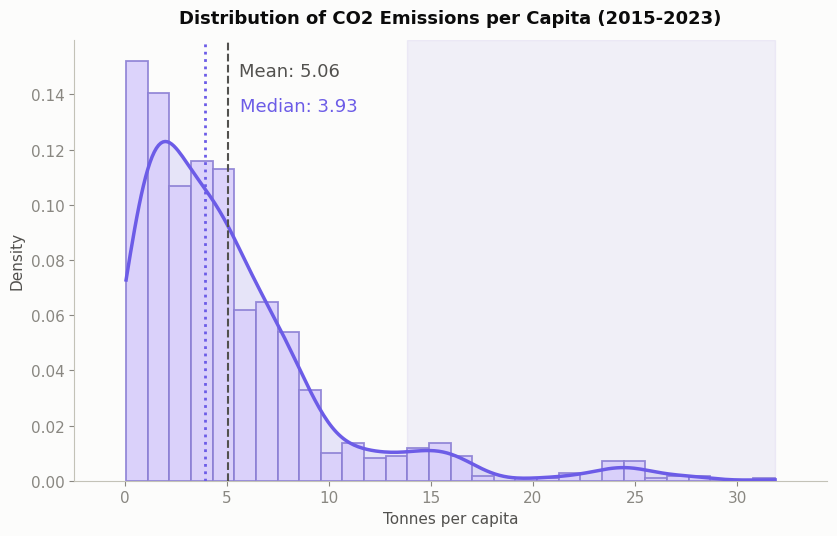

Saved: /content/drive/MyDrive/Predictive Analytics Course/charts/environmental_hist_pm25.png


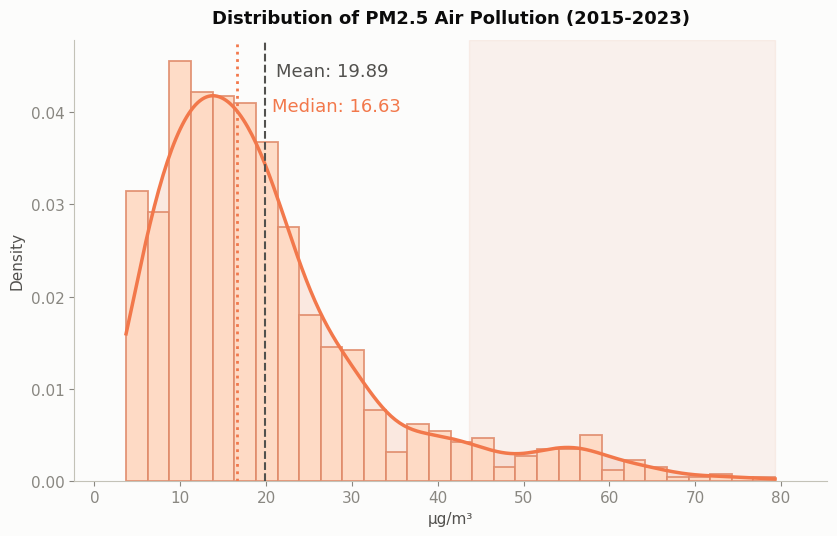

In [13]:
# Lets make a visualization to see the distribution of those columns

from scipy.stats import gaussian_kde
import matplotlib.transforms as transforms

def plot_pastel_histogram(series, title, xlabel, filename, fill_color, edge_color, accent_color):
    set_style()
    data = series.dropna()
    flag, lower, upper = iqr_outliers(data)

    fig, ax = plt.subplots(figsize=(8.5, 5.5))
    ax.margins(x=0.08)  # a little breathing room so the right-side labels don't clip

    if (data < lower).any():
        ax.axvspan(data.min(), lower, color=edge_color, alpha=0.10, zorder=0)
    if (data > upper).any():
        ax.axvspan(upper, data.max(), color=edge_color, alpha=0.10, zorder=0)

    ax.hist(data, bins=30, color=fill_color, edgecolor=edge_color, linewidth=1.3,
            alpha=0.9, density=True, zorder=2)

    kde = gaussian_kde(data)
    xs = np.linspace(data.min(), data.max(), 300)
    ax.plot(xs, kde(xs), color=accent_color, linewidth=2.5, zorder=3)
    ax.fill_between(xs, kde(xs), color=accent_color, alpha=0.15, zorder=1)

    mean_val, median_val = data.mean(), data.median()
    ax.axvline(mean_val, color=INK_SECONDARY, linestyle="--", linewidth=1.5, zorder=4)
    ax.axvline(median_val, color=accent_color, linestyle=":", linewidth=2, zorder=4)

    # values placed just right of each line; y is a fixed fraction of plot height, so
    # it stays near the top no matter what the density axis scale is
    trans = transforms.blended_transform_factory(ax.transData, ax.transAxes)
    ax.annotate(f"Mean: {mean_val:.2f}", xy=(mean_val, 0.95), xycoords=trans,
                xytext=(8, 0), textcoords="offset points",
                ha="left", va="top", fontsize=13, color=INK_SECONDARY)
    ax.annotate(f"Median: {median_val:.2f}", xy=(median_val, 0.87), xycoords=trans,
                xytext=(25, 0), textcoords="offset points",
                ha="left", va="top", fontsize=13, color=accent_color)

    ax.set_title(title, fontsize=13, fontweight="bold", pad=12)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Density")
    ax.grid(False)
    save_chart(fig, filename)

# soft lavender for CO2, soft peach for PM2.5
plot_pastel_histogram(env["CO2_Emissions_Per_Capita"], "Distribution of CO2 Emissions per Capita (2015-2023)",
                       "Tonnes per capita", "environmental_hist_co2",
                       fill_color="#D9CFFB", edge_color="#8B7FD4", accent_color="#6C5CE7")

plot_pastel_histogram(env["PM25_Air_Pollution_ug_m3"], "Distribution of PM2.5 Air Pollution (2015-2023)",
                       "µg/m³", "environmental_hist_pm25",
                       fill_color="#FFD9C2", edge_color="#E08B6B", accent_color="#F2784B")

## 6. Descriptive statistics

In [14]:
overall_desc = env[ENV_COLS].describe().T
overall_desc["skew"] = env[ENV_COLS].skew()
overall_desc.round(2)

,count,mean,std,min,25%,50%,75%,max,skew
CO2_Emissions_Per_Capita,1035.0,5.06,4.86,0.07,1.81,3.93,6.61,31.86,2.15
PM25_Air_Pollution_ug_m3,1035.0,19.89,13.12,3.68,10.96,16.63,24.02,79.30,1.60


In [15]:
region_desc = (
    env.groupby("Region")[ENV_COLS]
    .agg(["mean", "median", "std", "min", "max"])
    .round(2)
)
region_desc

CO2_Emissions_Per_Capita                      \
                                               mean median   std    min   
Region                                                                    
East Asia & Pacific                            4.87   2.93  4.68   0.41   
Europe & Central Asia                          6.65   6.12  2.88   1.46   
Latin America & Caribbean                      3.70   2.42  4.81   0.71   
Middle East & North Africa                     6.45   3.09  7.73   0.25   
North America                                 15.00  15.28  0.85  13.73   
South Asia                                     1.58   1.30  1.13   0.25   
Sub-Saharan Africa                             1.73   0.64  2.27   0.07   

                                  PM25_Air_Pollution_ug_m3                \
                              max                     mean median    std   
Region                                                                     
East Asia & Pacific         16.84                    17.99  18.98  12.56   
Europe & Central Asia       17.41                    14.07  13.35   5.98   
Latin America & Caribbean   31.86                    17.33  16.62   6.73   
Middle East & North Africa  25.98                    34.24  32.16  16.66   
North America               16.46                     7.19   7.33   0.66   
South Asia                   4.23                    40.48  42.14  20.02   
Sub-Saharan Africa           8.06                    23.27  20.22  10.80   

                                          
                              min    max  
Region                                    
East Asia & Pacific          3.68  49.47  
Europe & Central Asia        4.43  31.69  
Latin America & Caribbean    5.03  36.54  
Middle East & North Africa  10.42  74.50  
North America                6.03   8.23  
South Asia                  10.41  79.30  
Sub-Saharan Africa           8.21  53.02

In [16]:
# Trend over time (2015-2023), overall
yearly_desc = env.groupby("Year")[ENV_COLS].mean().round(2)
yearly_desc


,CO2_Emissions_Per_Capita,PM25_Air_Pollution_ug_m3
Year,,
2015,5.25,20.72
2016,5.22,20.04
2017,5.26,20.20
2018,5.26,20.48
2019,5.21,19.50
2020,4.76,19.28
2021,4.89,19.71
2022,4.94,19.83
2023,4.80,19.21


## 7. Trend charts (2015-2023, by region)

Two charts, one per variable, following the shared style. Region colours are fixed by `region_color_map()` so the same region gets the same color ans in Person 1 and Person 2'1 charts, if they plot by region too.

Saved: /content/drive/MyDrive/Predictive Analytics Course/charts/environmental_trend_co2.png


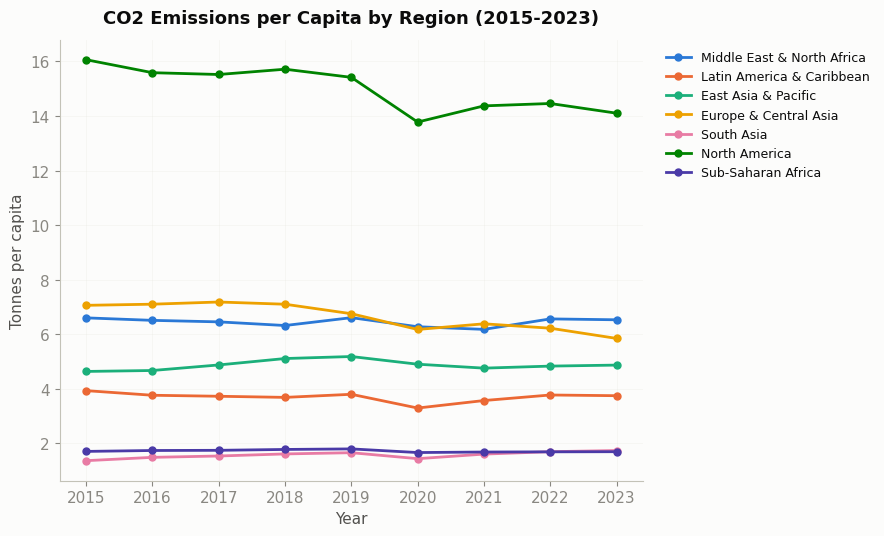

In [62]:
def plot_regional_trend(data, value_col, title, ylabel, filename):
    set_style()
    regions = data.sort_values("Year")["Region"].tolist()
    colors = region_color_map(data["Region"].unique())

    fig, ax = plt.subplots(figsize=(9, 5.5))
    trend = data.groupby(["Year", "Region"])[value_col].mean().reset_index()

    for region, color in colors.items():
        sub = trend[trend["Region"] == region].sort_values("Year")
        ax.plot(sub["Year"], sub[value_col], marker="o", markersize=5,
                linewidth=2, color=color, label=region)

    ax.set_title(title, fontsize=13, fontweight="bold", pad=12)
    ax.set_xlabel("Year")
    ax.set_ylabel(ylabel)
    ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    ax.grid(True, alpha=0.3, linewidth=0.5)
    ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1), fontsize=9)
    save_chart(fig, filename)
    return trend

co2_trend = plot_regional_trend(
    env, "CO2_Emissions_Per_Capita",
    "CO2 Emissions per Capita by Region (2015-2023)",
    "Tonnes per capita",
    "environmental_trend_co2",
)

Saved: /content/drive/MyDrive/Predictive Analytics Course/charts/environmental_trend_pm25.png


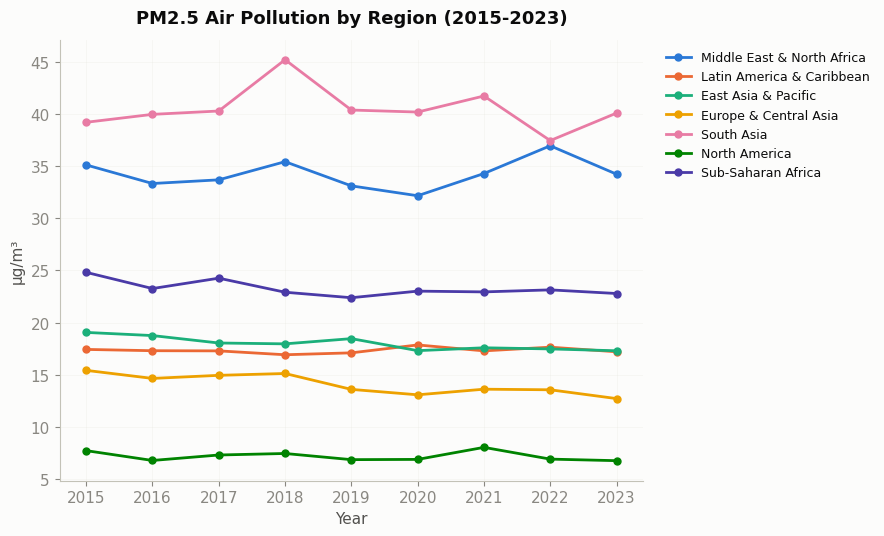

In [63]:
pm25_trend = plot_regional_trend(
    env.dropna(subset=["PM25_Air_Pollution_ug_m3"]), "PM25_Air_Pollution_ug_m3",
    "PM2.5 Air Pollution by Region (2015-2023)",
    "µg/m³",
    "environmental_trend_pm25",
)

Saved: /content/drive/MyDrive/Predictive Analytics Course/charts/environmental_avg_co2.png


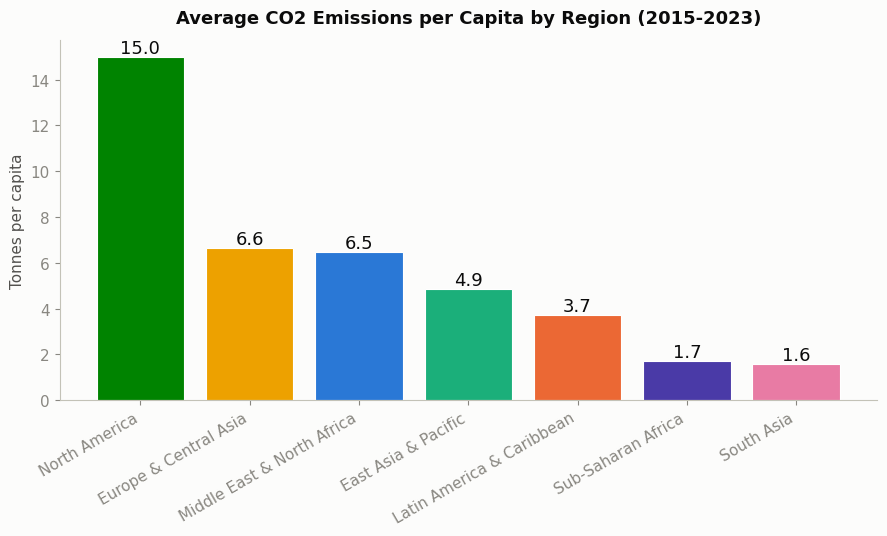

Saved: /content/drive/MyDrive/Predictive Analytics Course/charts/environmental_avg_pm25.png


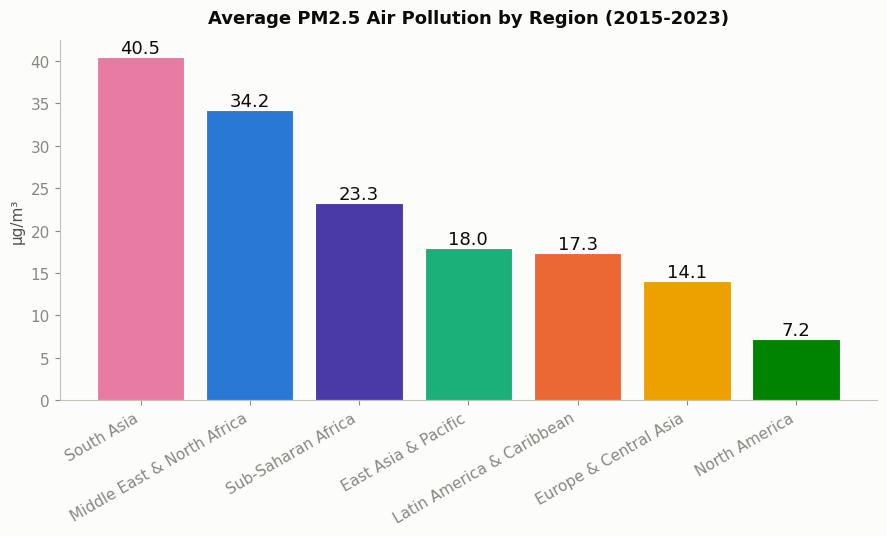

In [19]:
def plot_regional_bar(data, value_col, title, ylabel, filename):
    set_style()
    avg = data.groupby("Region")[value_col].mean().sort_values(ascending=False)
    colors_map = region_color_map(data["Region"].unique())
    colors = [colors_map[r] for r in avg.index]

    fig, ax = plt.subplots(figsize=(9, 5.5))
    bars = ax.bar(avg.index, avg.values, color=colors, edgecolor="white", linewidth=0.8)

    for bar, val in zip(bars, avg.values):
        ax.text(bar.get_x() + bar.get_width() / 2, val, f"{val:.1f}",
                ha="center", va="bottom", fontsize=13, color=INK_PRIMARY)

    ax.set_title(title, fontsize=13, fontweight="bold", pad=12)
    ax.set_ylabel(ylabel)
    plt.setp(ax.get_xticklabels(), rotation=30, ha="right")
    ax.grid(False)
    save_chart(fig, filename)
    return avg

co2_avg = plot_regional_bar(
    env, "CO2_Emissions_Per_Capita",
    "Average CO2 Emissions per Capita by Region (2015-2023)",
    "Tonnes per capita", "environmental_avg_co2",
)

pm25_avg = plot_regional_bar(
    env.dropna(subset=["PM25_Air_Pollution_ug_m3"]), "PM25_Air_Pollution_ug_m3",
    "Average PM2.5 Air Pollution by Region (2015-2023)",
    "µg/m³", "environmental_avg_pm25",
)

Saved: /content/drive/MyDrive/Predictive Analytics Course/charts/environmental_overall_trend_co2.png


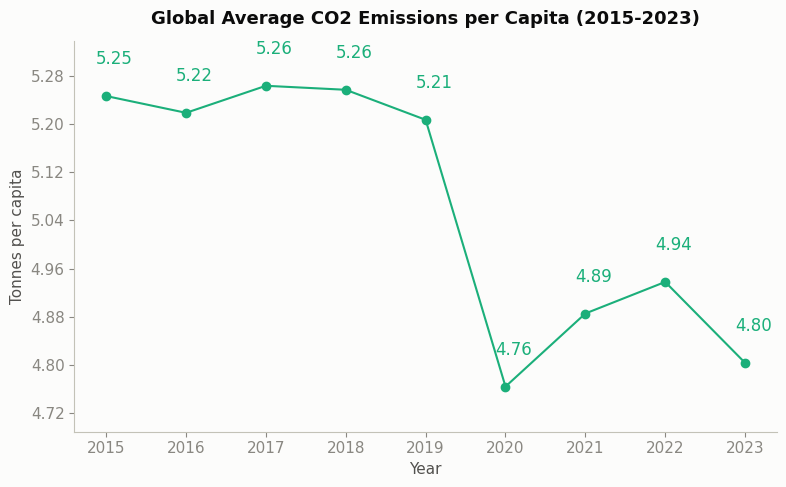

In [20]:
def plot_overall_trend(data, value_col, title, ylabel, filename, line_color="#1baf7a"):
    set_style()
    yearly = data.groupby("Year")[value_col].mean().reset_index()
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.margins(y=0.15)  # headroom so labels near the top don't get clipped
    ax.plot(yearly["Year"], yearly[value_col], marker="o", markersize=6,
            linewidth=1.5, color=line_color)

    for x, y in zip(yearly["Year"], yearly[value_col]):
        ax.annotate(f"{y:.2f}", xy=(x, y), xytext=(6, 23), textcoords="offset points",
                    ha="center", fontsize=12, color=line_color)

    ax.set_title(title, fontsize=13, fontweight="bold", pad=12)
    ax.set_xlabel("Year")
    ax.set_ylabel(ylabel)
    ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    ax.yaxis.set_major_locator(mticker.MaxNLocator(nbins=10))
    ax.grid(False)
    save_chart(fig, filename)

plot_overall_trend(
    env, "CO2_Emissions_Per_Capita",
    "Global Average CO2 Emissions per Capita (2015-2023)",
    "Tonnes per capita",
    "environmental_overall_trend_co2",
    line_color="#1baf7a",
)

## 8. Export summary CSV

In [21]:
# Per the group's shared convention: one summary-statistics CSV per person, ready to drop into the report.
summary_path = Path(CHARTS_DIR).parent / "environmental_summary.csv"

summary_export = region_desc.copy()
summary_export.columns = ["_".join(col).strip() for col in summary_export.columns.values]
summary_export = summary_export.reset_index()

summary_export.to_csv(summary_path, index=False)
print(f"Saved: {summary_path}")
summary_export

Saved: /content/drive/MyDrive/Predictive Analytics Course/environmental_summary.csv


,Region,CO2_Emissions_Per_Capita_mean,CO2_Emissions_Per_Capita_median,CO2_Emissions_Per_Capita_std,CO2_Emissions_Per_Capita_min,CO2_Emissions_Per_Capita_max,PM25_Air_Pollution_ug_m3_mean,PM25_Air_Pollution_ug_m3_median,PM25_Air_Pollution_ug_m3_std,PM25_Air_Pollution_ug_m3_min,PM25_Air_Pollution_ug_m3_max
0,East Asia & Pacific,4.87,2.93,4.68,0.41,16.84,17.99,18.98,12.56,3.68,49.47
1,Europe & Central Asia,6.65,6.12,2.88,1.46,17.41,14.07,13.35,5.98,4.43,31.69
2,Latin America & Caribbean,3.70,2.42,4.81,0.71,31.86,17.33,16.62,6.73,5.03,36.54
3,Middle East & North Africa,6.45,3.09,7.73,0.25,25.98,34.24,32.16,16.66,10.42,74.50
4,North America,15.00,15.28,0.85,13.73,16.46,7.19,7.33,0.66,6.03,8.23
5,South Asia,1.58,1.30,1.13,0.25,4.23,40.48,42.14,20.02,10.41,79.30
6,Sub-Saharan Africa,1.73,0.64,2.27,0.07,8.06,23.27,20.22,10.80,8.21,53.02


In [64]:
# Split into two separate tables — one per environmental variable
co2_summary = region_desc["CO2_Emissions_Per_Capita"].copy()
pm25_summary = region_desc["PM25_Air_Pollution_ug_m3"].copy()

co2_summary_export = co2_summary.reset_index()
pm25_summary_export = pm25_summary.reset_index()

co2_path = Path(CHARTS_DIR).parent / "environmental_summary_co2.csv"
pm25_path = Path(CHARTS_DIR).parent / "environmental_summary_pm25.csv"

co2_summary_export.to_csv(co2_path, index=False)
pm25_summary_export.to_csv(pm25_path, index=False)
print(f"Saved: {co2_path}")
print(f"Saved: {pm25_path}")

print("\nCO2 Emissions per Capita — Regional Summary")
display(co2_summary_export)

print("\nPM2.5 Air Pollution — Regional Summary")
display(pm25_summary_export)

Saved: /content/drive/MyDrive/Predictive Analytics Course/environmental_summary_co2.csv
Saved: /content/drive/MyDrive/Predictive Analytics Course/environmental_summary_pm25.csv

CO2 Emissions per Capita — Regional Summary


,Region,mean,median,std,min,max
0,East Asia & Pacific,4.87,2.93,4.68,0.41,16.84
1,Europe & Central Asia,6.65,6.12,2.88,1.46,17.41
2,Latin America & Caribbean,3.70,2.42,4.81,0.71,31.86
3,Middle East & North Africa,6.45,3.09,7.73,0.25,25.98
4,North America,15.00,15.28,0.85,13.73,16.46
5,South Asia,1.58,1.30,1.13,0.25,4.23
6,Sub-Saharan Africa,1.73,0.64,2.27,0.07,8.06



PM2.5 Air Pollution — Regional Summary


,Region,mean,median,std,min,max
0,East Asia & Pacific,17.99,18.98,12.56,3.68,49.47
1,Europe & Central Asia,14.07,13.35,5.98,4.43,31.69
2,Latin America & Caribbean,17.33,16.62,6.73,5.03,36.54
3,Middle East & North Africa,34.24,32.16,16.66,10.42,74.50
4,North America,7.19,7.33,0.66,6.03,8.23
5,South Asia,40.48,42.14,20.02,10.41,79.30
6,Sub-Saharan Africa,23.27,20.22,10.80,8.21,53.02


Good choice — since it only needs your two variables, it's fully self-contained in your section and gives you real material for "risks/opportunities" instead of just regional averages. Here's the plan, in order.

1. Build one row per country (not country-year). Segmentation is about identifying stable environmental profiles, so we average CO2 and PM2.5 over 2015–2023 per country rather than clustering every country-year separately — that would just cluster years, not countries. Countries with zero PM2.5 coverage (the ones from your Section 4 diagnostics) drop out here, which is worth naming as a limitation.

In [22]:
country_profile = (
    env.groupby(["Country", "Region"])[["CO2_Emissions_Per_Capita", "PM25_Air_Pollution_ug_m3"]]
    .mean()
    .dropna()
    .reset_index()
)
print(f"Countries available for clustering: {len(country_profile)} of {env['Country'].nunique()}")
print(f"Excluded (no PM2.5 coverage): {env['Country'].nunique() - len(country_profile)}")

Countries available for clustering: 115 of 115
Excluded (no PM2.5 coverage): 0


In [23]:
country_profile.head()

,Country,Region,CO2_Emissions_Per_Capita,PM25_Air_Pollution_ug_m3
0,Afghanistan,Middle East & North Africa,0.263777,37.568535
1,Algeria,Middle East & North Africa,4.083219,16.461029
2,Argentina,Latin America & Caribbean,4.096352,14.407231
3,Australia,East Asia & Pacific,15.856907,6.326110
4,Austria,Europe & Central Asia,7.308297,11.751032


2. Standardize, then pick k with silhouette score. CO2 (0–16 tonnes) and PM2.5 (0–45 µg/m³) are on different scales, so K-means needs standardized features or PM2.5's larger numbers would dominate the distance calculation. Silhouette score across a few k values gives a defensible, non-arbitrary choice of k for the methodology section instead of just picking a number.

In [24]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

features = ["CO2_Emissions_Per_Capita", "PM25_Air_Pollution_ug_m3"]
scaler = StandardScaler()
X = scaler.fit_transform(country_profile[features])

sil_scores = {}
for k in range(2, 7):
    labels = KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(X)
    sil_scores[k] = silhouette_score(X, labels)
    print(f"k={k}: silhouette={sil_scores[k]:.3f}")

best_k = max(sil_scores, key=sil_scores.get)
print(f"\nBest k by silhouette score: {best_k}")

k=2: silhouette=0.555
k=3: silhouette=0.492
k=4: silhouette=0.430
k=5: silhouette=0.366
k=6: silhouette=0.369

Best k by silhouette score: 2


Saved: /content/drive/MyDrive/Predictive Analytics Course/charts/environmental_clusters_before.png


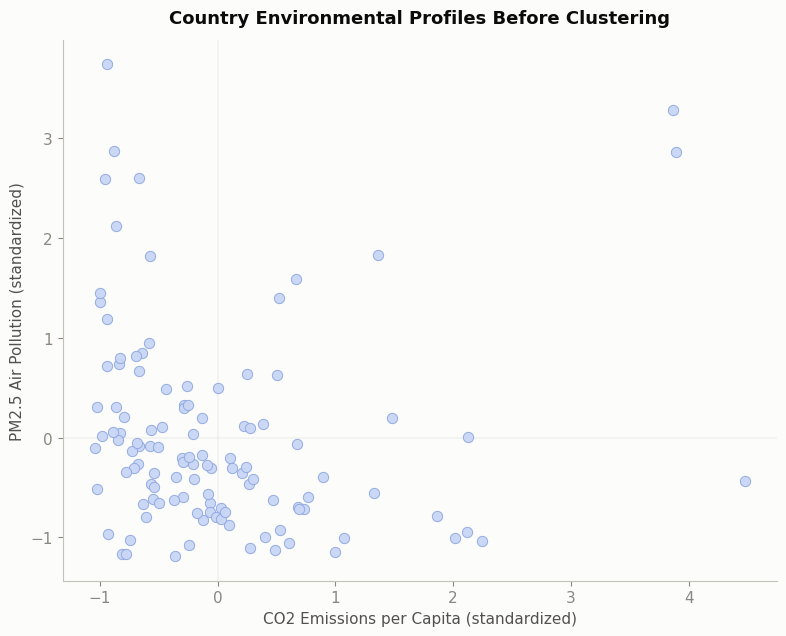

In [36]:
set_style()
fig, ax = plt.subplots(figsize=(8, 6.5))

ax.scatter(X[:, 0], X[:, 1], s=55, alpha=0.95,
           color="#C9D6F5", edgecolor="#8FA8E0", linewidth=0.7)
ax.axhline(0, color=BASELINE, linewidth=0.2, zorder=0)
ax.axvline(0, color=BASELINE, linewidth=0.2, zorder=0)

ax.set_title("Country Environmental Profiles Before Clustering", fontsize=13, fontweight="bold", pad=12)
ax.set_xlabel("CO2 Emissions per Capita (standardized)")
ax.set_ylabel("PM2.5 Air Pollution (standardized)")
ax.grid(False)

save_chart(fig, "environmental_clusters_before")

In [26]:
from sklearn.metrics import calinski_harabasz_score

sil_scores = {}
ch_scores = {}
for k in range(2, 7):
    labels = KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(X)
    sil_scores[k] = silhouette_score(X, labels)
    ch_scores[k] = calinski_harabasz_score(X, labels)
    print(f"k={k}: silhouette={sil_scores[k]:.3f}  |  calinski-harabasz={ch_scores[k]:.1f}")

best_k = max(sil_scores, key=sil_scores.get)
best_ch_k = max(ch_scores, key=ch_scores.get)
print(f"\nBest k by silhouette score: {best_k}")
print(f"Best k by Calinski-Harabasz index: {best_ch_k}")

k=2: silhouette=0.555  |  calinski-harabasz=57.1
k=3: silhouette=0.492  |  calinski-harabasz=76.1
k=4: silhouette=0.430  |  calinski-harabasz=90.6
k=5: silhouette=0.366  |  calinski-harabasz=95.3
k=6: silhouette=0.369  |  calinski-harabasz=99.9

Best k by silhouette score: 2
Best k by Calinski-Harabasz index: 6


Saved: /content/drive/MyDrive/Predictive Analytics Course/charts/environmental_clusters_silhouette.png


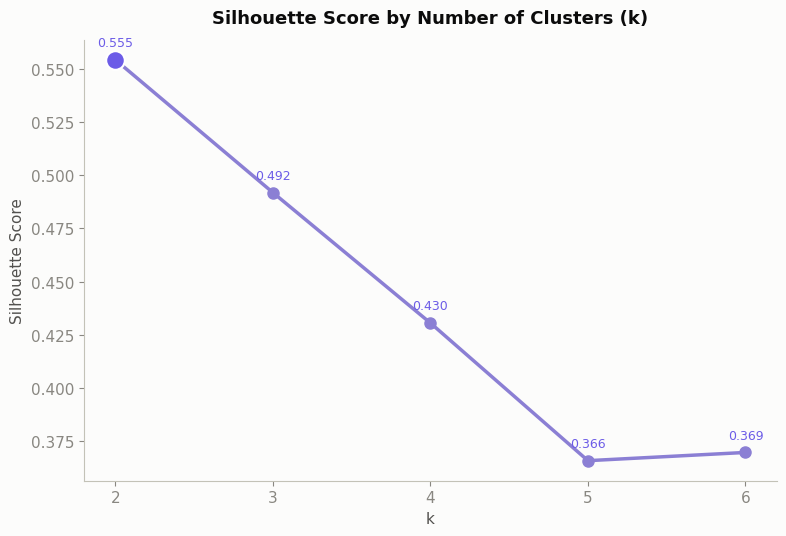

In [27]:
set_style()
fig, ax = plt.subplots(figsize=(8, 5.5))
ks, vals = list(sil_scores.keys()), list(sil_scores.values())

ax.plot(ks, vals, marker="o", markersize=8, linewidth=2.5, color="#8B7FD4")
ax.scatter([best_k], [sil_scores[best_k]], s=180, color="#6C5CE7",
           edgecolor="white", linewidth=1.5, zorder=5)
for x, y in zip(ks, vals):
    ax.annotate(f"{y:.3f}", xy=(x, y), xytext=(0, 10), textcoords="offset points",
                ha="center", fontsize=9, color="#6C5CE7")

ax.set_title("Silhouette Score by Number of Clusters (k)", fontsize=13, fontweight="bold", pad=12)
ax.set_xlabel("k")
ax.set_ylabel("Silhouette Score")
ax.set_xticks(ks)
ax.grid(False)
save_chart(fig, "environmental_clusters_silhouette")

Saved: /content/drive/MyDrive/Predictive Analytics Course/charts/environmental_clusters_calinski_harabasz.png


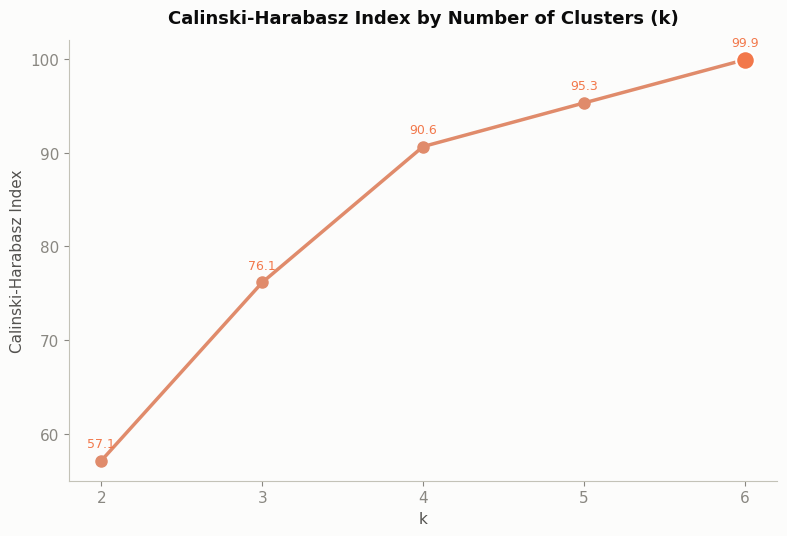

In [28]:
set_style()
fig, ax = plt.subplots(figsize=(8, 5.5))
ks, vals = list(ch_scores.keys()), list(ch_scores.values())

ax.plot(ks, vals, marker="o", markersize=8, linewidth=2.5, color="#E08B6B")
ax.scatter([best_ch_k], [ch_scores[best_ch_k]], s=180, color="#F2784B",
           edgecolor="white", linewidth=1.5, zorder=5)
for x, y in zip(ks, vals):
    ax.annotate(f"{y:.1f}", xy=(x, y), xytext=(0, 10), textcoords="offset points",
                ha="center", fontsize=9, color="#F2784B")

ax.set_title("Calinski-Harabasz Index by Number of Clusters (k)", fontsize=13, fontweight="bold", pad=12)
ax.set_xlabel("k")
ax.set_ylabel("Calinski-Harabasz Index")
ax.set_xticks(ks)
ax.grid(False)
save_chart(fig, "environmental_clusters_calinski_harabasz")

In [29]:
inertia_scores = {}
for k in range(1, 7):
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X)
    inertia_scores[k] = km.inertia_
    print(f"k={k}: inertia={inertia_scores[k]:.1f}")

k=1: inertia=230.0
k=2: inertia=152.8
k=3: inertia=97.5
k=4: inertia=66.7
k=5: inertia=51.5
k=6: inertia=41.2


Saved: /content/drive/MyDrive/Predictive Analytics Course/charts/environmental_clusters_elbow.png


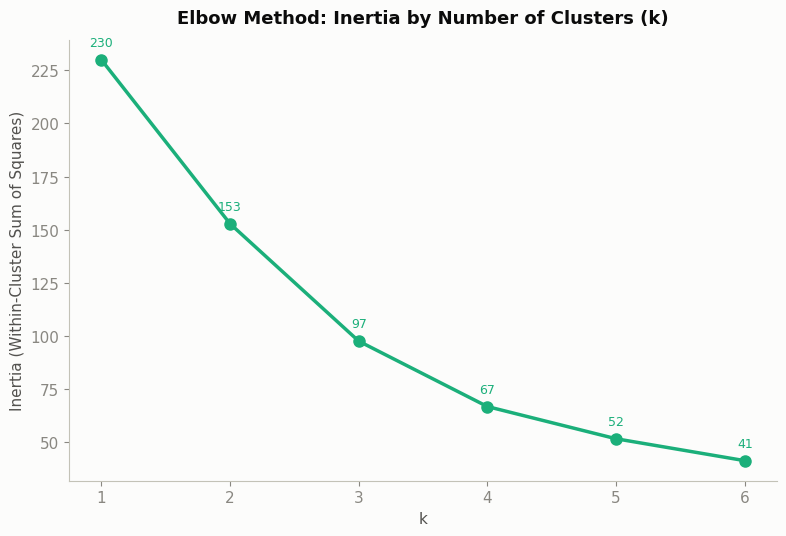

In [30]:
set_style()
fig, ax = plt.subplots(figsize=(8, 5.5))
ks, vals = list(inertia_scores.keys()), list(inertia_scores.values())

ax.plot(ks, vals, marker="o", markersize=8, linewidth=2.5, color="#1baf7a")
for x, y in zip(ks, vals):
    ax.annotate(f"{y:.0f}", xy=(x, y), xytext=(0, 10), textcoords="offset points",
                ha="center", fontsize=9, color="#1baf7a")

ax.set_title("Elbow Method: Inertia by Number of Clusters (k)", fontsize=13, fontweight="bold", pad=12)
ax.set_xlabel("k")
ax.set_ylabel("Inertia (Within-Cluster Sum of Squares)")
ax.set_xticks(ks)
ax.grid(False)
save_chart(fig, "environmental_clusters_elbow")

In [31]:
K = 3  # selected by balancing silhouette, Calinski-Harabasz, and the elbow method (see analysis above)

kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
country_profile["cluster"] = kmeans.fit_predict(X)

centroids = pd.DataFrame(scaler.inverse_transform(kmeans.cluster_centers_), columns=features)
centroids["cluster"] = range(K)
centroids["combined_rank"] = centroids[features].rank().sum(axis=1)
centroids_sorted = centroids.sort_values("combined_rank")

label_names = ["Clean / Low Impact", "Transitional / Mixed", "High Emission / High Pollution"]
cluster_label_map = dict(zip(centroids_sorted["cluster"], label_names))
country_profile["cluster_label"] = country_profile["cluster"].map(cluster_label_map)

centroids_sorted

,CO2_Emissions_Per_Capita,PM25_Air_Pollution_ug_m3,cluster,combined_rank
1,4.227132,15.089287,1,3.0
2,2.425730,40.516604,2,4.0
0,17.282668,21.932048,0,5.0


Saved: /content/drive/MyDrive/Predictive Analytics Course/charts/environmental_clusters_after.png


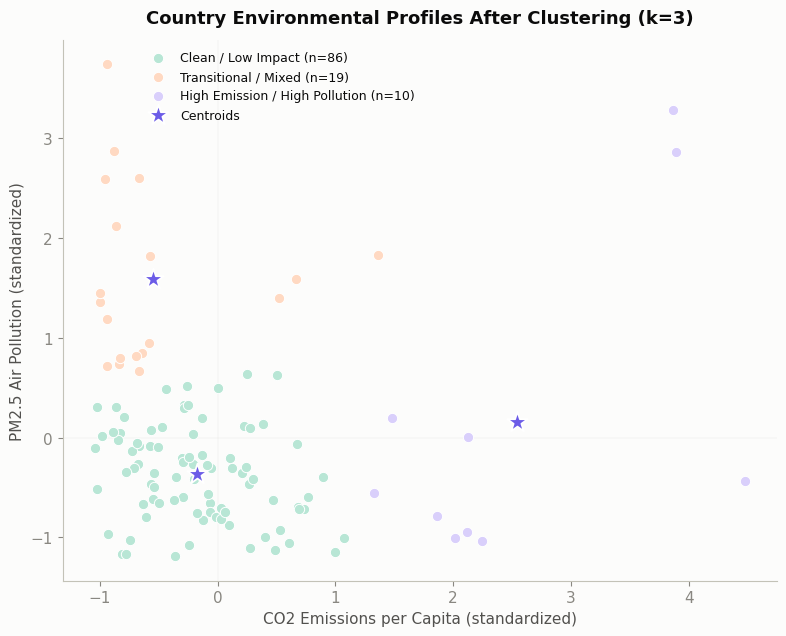

In [45]:
CLUSTER_COLORS = ["#B8E6D5", "#FFD9C2", "#D9CFFB"]

set_style()
fig, ax = plt.subplots(figsize=(8, 6.5))

for i, lab in enumerate(label_names):
    mask = country_profile["cluster_label"] == lab
    ax.scatter(X[mask.values, 0], X[mask.values, 1], s=55, alpha=1,
               color=CLUSTER_COLORS[i], edgecolor="white", linewidth=0.7,
               label=f"{lab} (n={mask.sum()})")

centers = kmeans.cluster_centers_
ax.scatter(centers[:, 0], centers[:, 1], s=240, marker="*",
           color="#6C5CE7", edgecolor="white", linewidth=1.3, zorder=5, label="Centroids")

ax.axhline(0, color=BASELINE, linewidth=0.1, zorder=0)
ax.axvline(0, color=BASELINE, linewidth=0.1, zorder=0)
ax.set_title("Country Environmental Profiles After Clustering (k=3)", fontsize=13, fontweight="bold", pad=12)
ax.set_xlabel("CO2 Emissions per Capita (standardized)")
ax.set_ylabel("PM2.5 Air Pollution (standardized)")
ax.grid(False)
ax.legend(loc="upper left", bbox_to_anchor=(0.1, 1), fontsize=9, framealpha=0.9)

save_chart(fig, "environmental_clusters_after")

In [33]:
cluster_summary = country_profile.groupby("cluster_label")[features].agg(["mean", "count"]).round(2)
display(cluster_summary)

for lab in label_names:
    sample = country_profile[country_profile["cluster_label"] == lab].sort_values(
        "CO2_Emissions_Per_Capita", ascending=False)
    print(f"\n{lab} (n={len(sample)}):")
    print(sample[["Country", "Region", "CO2_Emissions_Per_Capita", "PM25_Air_Pollution_ug_m3"]]
          .head(5).to_string(index=False))

cluster_export_path = Path(CHARTS_DIR).parent / "environmental_country_clusters.csv"
country_profile.to_csv(cluster_export_path, index=False)
print(f"Saved: {cluster_export_path}")

CO2_Emissions_Per_Capita        \
                                                   mean count   
cluster_label                                                   
Clean / Low Impact                                 4.23    86   
High Emission / High Pollution                    17.28    10   
Transitional / Mixed                               2.43    19   

                               PM25_Air_Pollution_ug_m3        
                                                   mean count  
cluster_label                                                  
Clean / Low Impact                                15.09    86  
High Emission / High Pollution                    21.93    10  
Transitional / Mixed                              40.52    19


Clean / Low Impact (n=86):
Country                Region  CO2_Emissions_Per_Capita  PM25_Air_Pollution_ug_m3
Estonia Europe & Central Asia                 10.232024                  6.808435
Iceland Europe & Central Asia                  9.871419                  4.908964
Czechia Europe & Central Asia                  9.381925                 14.796051
  Japan   East Asia & Pacific                  8.757731                 12.115170
Germany Europe & Central Asia                  8.580767                 10.609548

Transitional / Mixed (n=19):
           Country                     Region  CO2_Emissions_Per_Capita  PM25_Air_Pollution_ug_m3
          Mongolia        East Asia & Pacific                 11.625403                 43.688744
Iran, Islamic Rep. Middle East & North Africa                  8.257791                 40.631069
             China        East Asia & Pacific                  7.580838                 38.116634
  Egypt, Arab Rep. Middle East & North Africa             

In [52]:
!pip install adjustText -q

Saved: /content/drive/MyDrive/Predictive Analytics Course/charts/environmental_clusters_after.png


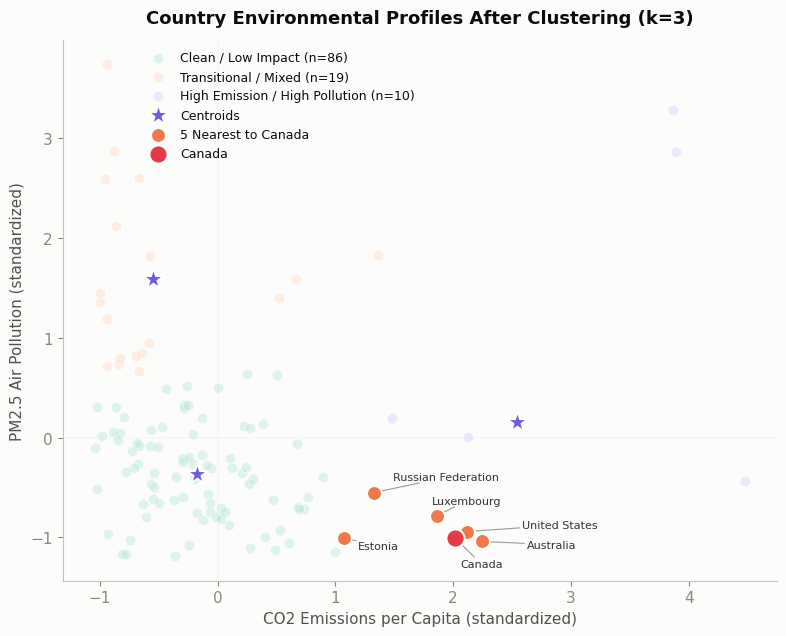

,Country,Region,Cluster,CO2 (t/capita),PM2.5 (µg/m³),Distance from Canada
20,Canada,North America,High Emission / High Pollution,14.75,6.76,0.00
110,United States,North America,High Emission / High Pollution,15.25,7.61,0.12
3,Australia,East Asia & Pacific,High Emission / High Pollution,15.86,6.33,0.23
64,Luxembourg,Europe & Central Asia,High Emission / High Pollution,14.03,9.68,0.27
90,Russian Federation,Europe & Central Asia,High Emission / High Pollution,11.46,12.70,0.82
34,Estonia,Europe & Central Asia,Clean / Low Impact,10.23,6.81,0.94


In [57]:
from adjustText import adjust_text

set_style()
fig, ax = plt.subplots(figsize=(8, 6.5))

for i, lab in enumerate(label_names):
    mask = country_profile["cluster_label"] == lab
    ax.scatter(X[mask.values, 0], X[mask.values, 1], s=55, alpha=0.45,
               color=CLUSTER_COLORS[i], edgecolor="white", linewidth=0.7,
               label=f"{lab} (n={mask.sum()})", zorder=2)

centers = kmeans.cluster_centers_
ax.scatter(centers[:, 0], centers[:, 1], s=240, marker="*",
           color="#6C5CE7", edgecolor="white", linewidth=1.3, zorder=5, label="Centroids")

ax.scatter(X[nearest5_idx, 0], X[nearest5_idx, 1], s=110, color="#F2784B",
           edgecolor="white", linewidth=1.2, zorder=6, label="5 Nearest to Canada")
ax.scatter(X[canada_idx, 0], X[canada_idx, 1], s=170, color="#E63946",
           edgecolor="white", linewidth=1.4, zorder=7, label="Canada")

# Place labels, then let adjustText spread out any that collide
texts = []
for idx in list(nearest5_idx) + [canada_idx]:
    texts.append(ax.text(X[idx, 0], X[idx, 1], country_profile.loc[idx, "Country"],
                          fontsize=8, color="#333333", zorder=8))

adjust_text(texts, ax=ax, arrowprops=dict(arrowstyle="-", color="#999999", lw=0.8),
            expand=(2, 1.8))

ax.axhline(0, color=BASELINE, linewidth=0.1, zorder=0)
ax.axvline(0, color=BASELINE, linewidth=0.1, zorder=0)
ax.set_title("Country Environmental Profiles After Clustering (k=3)", fontsize=13, fontweight="bold", pad=12)
ax.set_xlabel("CO2 Emissions per Capita (standardized)")
ax.set_ylabel("PM2.5 Air Pollution (standardized)")
ax.grid(False)
ax.legend(loc="upper left", bbox_to_anchor=(0.1, 1), fontsize=9, framealpha=0.9)

save_chart(fig, "environmental_clusters_after")

# ---- Table: Canada + its 5 nearest neighbors ----
canada_group = pd.concat([country_profile.loc[[canada_idx]], nearest5]).sort_values("dist_to_canada")
canada_group_table = canada_group[[
    "Country", "Region", "cluster_label",
    "CO2_Emissions_Per_Capita", "PM25_Air_Pollution_ug_m3", "dist_to_canada"
]].round(2)
canada_group_table.columns = ["Country", "Region", "Cluster", "CO2 (t/capita)", "PM2.5 (\u00b5g/m\u00b3)", "Distance from Canada"]
display(canada_group_table)